# SVM Exercises

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [4]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE
data = pd.read_csv(url, names=names)
invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)

data.head()

/tmp/ipykernel_3483/858683622.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation, and test sets with a test size of 25%

In [5]:
# YOUR CODE HERE
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']
y_col = 'class'

test_size = 25
X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [6]:
# YOUR CODE HERE
svm = SVC(gamma=1, C=1)
svm.fit(X_train, y_train)

SVC(C=1, gamma=1)

Print accuracy of training and validation data

In [7]:
# YOUR CODE HERE
y_train_pred=svm.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=svm.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  60.0


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [8]:
# YOUR CODE HERE
svm = SVC(gamma=.001, C=1)
svm.fit(X_train, y_train)

SVC(C=1, gamma=0.001)

Print accuracy of training and validation data

In [9]:
# YOUR CODE HERE
y_train_pred=svm.predict(X_train)
print("Training Accuracy is", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=svm.predict(X_val)
y_val_pred=svm.predict(X_val)
print("Validation Accuracy is", accuracy_score(y_val, y_val_pred)*100)

Training Accuracy is 88.88888888888889
Validation Accuracy is 68.0


Explain the accuracy results below.

(The high gamma value has 100% testing accuracy but 60% validation accuracy, meaning that the mode is overfit. The low gamma value has 89% testing accuracy and 68% validation accuracy, so it is a better fit.)

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

High Gamma Confusion Matrix (gamma=1):
[[15  0]
 [10  0]]

Low Gamma Confusion Matrix (gamma=0.001):
[[14  1]
 [ 7  3]]


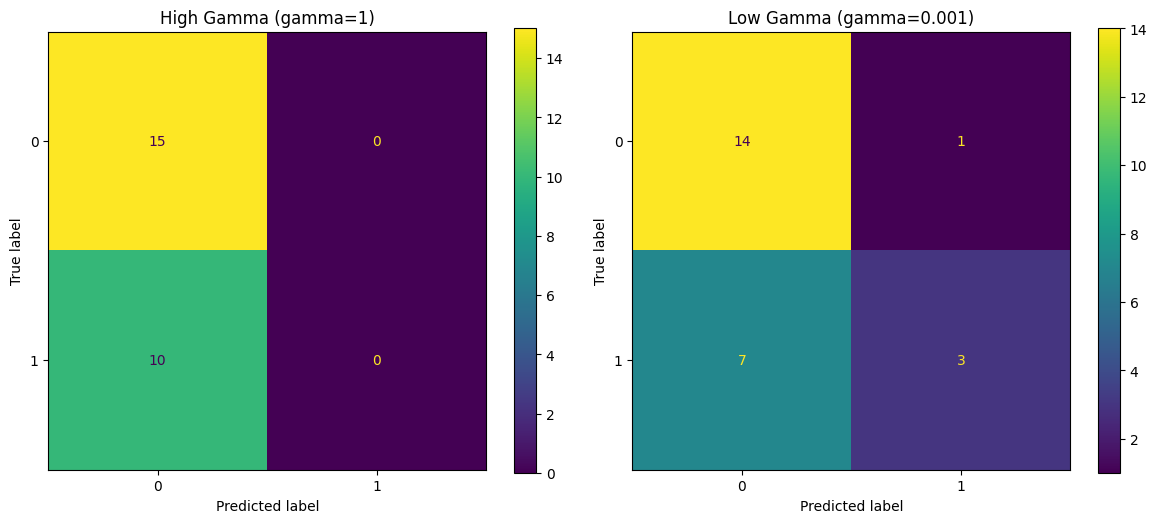

In [18]:
# YOUR CODE HERE
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


svm_high = SVC(gamma=1, C=1)
svm_high.fit(X_train, y_train)
y_val_pred_high = svm_high.predict(X_val)

svm_low = SVC(gamma=0.001, C=1)
svm_low.fit(X_train, y_train)
y_val_pred_low = svm_low.predict(X_val)



cm_high = confusion_matrix(y_val, y_val_pred_high)
cm_low = confusion_matrix(y_val, y_val_pred_low)

print("High Gamma Confusion Matrix (gamma=1):")
print(cm_high)

print("\nLow Gamma Confusion Matrix (gamma=0.001):")
print(cm_low)



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_high).plot(ax=axes[0])
axes[0].set_title("High Gamma (gamma=1)")

ConfusionMatrixDisplay(confusion_matrix=cm_low).plot(ax=axes[1])
axes[1].set_title("Low Gamma (gamma=0.001)")

plt.tight_layout()
plt.show()

